In [1]:
%load_ext autoreload
%autoreload 2
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import normflows as nf
import formula as fo
import summarize as su
import getplot as pl
import time
from torch.distributions import Normal

torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def make_data(n=200, p=100, sigma2=0.5, beta_signal=None, device="cpu"):
    if beta_signal is None:
        beta_signal = [1.5, -0.8, 0.7, -1.2, 0.5]

    beta_signal = torch.as_tensor(beta_signal, dtype=torch.float32, device=device)
    k = len(beta_signal)

    if k > p:
        raise ValueError("len(beta_signal) cannot exceed p")

    X = torch.randn(n, p, device=device)
    beta_true = torch.zeros(p, device=device)
    beta_true[:k] = beta_signal

    eps = math.sqrt(sigma2) * torch.randn(n, device=device)
    y = X @ beta_true + eps

    return X, y, beta_true

In [3]:
def sumfun1(model, target_dist, n_post_samples=5000, gate_threshold=0.5, inclusion_threshold=0.5,
    beta_true=None, pip_true=None, X_train=None, y_train=None, X_test=None, y_test=None,
    exact_gaussian_mean=None, exact_gaussian_cov=None, losses=None, tau_hist=None, make_plots=True,):

    t0 = time.time()

    post = su.postsum(model=model, target_dist=target_dist, n_samples=n_post_samples,
        gate_threshold=gate_threshold, inclusion_threshold=inclusion_threshold,)

    results = su.res_wrapper(post_summary=post, beta_true=beta_true,
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, pip_true=pip_true,
        exact_gaussian_mean=exact_gaussian_mean, exact_gaussian_cov=exact_gaussian_cov,)

    elapsed = time.time() - t0
    results["evaluation_time_sec"] = elapsed

    su.print_evaluation(results, post_summary=post)

    if make_plots:
        if losses is not None and tau_hist is not None:
            pl.plot_training(losses, tau_hist)

        pl.plot_posterior_inclusion_prob(
            posterior_inclusion_prob=post["pip"],
            beta_true=beta_true,
            top_k=min(30, post["pip"].numel()),
            decision_threshold=inclusion_threshold,
        )

        if beta_true is not None:
            # pick representative variables: null / signal if possible
            beta_true_cpu = fo._to_cpu(beta_true)
            nonzero_idx = torch.nonzero(beta_true_cpu != 0, as_tuple=False).squeeze(1).tolist()
            zero_idx = torch.nonzero(beta_true_cpu == 0, as_tuple=False).squeeze(1).tolist()

            chosen = []
            chosen.extend(zero_idx[:2])
            chosen.extend(nonzero_idx[:4])
            chosen = chosen[:6] if len(chosen) > 6 else chosen

            if len(chosen) > 0:
                pl.plot_beta_marginals(post, beta_true=beta_true, variable_indices=chosen, use_hard=False)
                pl.plot_beta_marginals(post, beta_true=beta_true, variable_indices=chosen, use_hard=True)

        if X_test is not None and y_test is not None:
            yhat_test_soft = X_test @ post["beta_soft_mean"]
            pl.plot_predictive_fit(y_test, yhat_test_soft, title="Test predictive fit (soft mean)")

    return post, results

In [ ]:
n = 200
p = 100
sigma2 = 0.5

X, y, beta_true = make_data(n=n, p=p, sigma2=sigma2, device=device,)

Sigma = torch.eye(p, device=device)

target_dist = fo.RelaxedSpikeSlabTarget(X=X, y=y, sigma2=sigma2, lambda_s=1.0, mu_t=0.0,
    sigma_t=1.0, tau=1.0, slab="laplace",).to(device)

flow_type = "affine_coupling"

model = fo.build_nf(latent_dim=target_dist.latent_dim, target_dist=target_dist,
    flow_type=flow_type, K=8, hidden_units=128, num_hidden_layers=2, device=device,)

losses, tau_hist = fo.train_flow(model=model, target_dist=target_dist,
    epochs=6000, num_samples=1024, lr=1e-3, tau_start=1.0, tau_end=0.1,
    kl_anneal=False, grad_clip=5.0, print_every=500,)

torch.save({"model_state_dict": model.state_dict(), "flow_type": flow_type, "latent_dim": target_dist.latent_dim,
    "K": 8, "hidden_units": 128, "num_hidden_layers": 2, "sigma2": sigma2, "losses": losses, 
    "tau_hist": tau_hist, "beta_true": beta_true, "X": X, "y": y,}, "run1_checkpoint.pt")


In [ ]:
ckpt = torch.load("run1_checkpoint.pt", map_location=device)

X = ckpt["X"].to(device)
y = ckpt["y"].to(device)
beta_true = ckpt["beta_true"].to(device)
sigma2 = ckpt["sigma2"]
flow_type = ckpt["flow_type"]
K = ckpt["K"]
hidden_units = ckpt["hidden_units"]
num_hidden_layers = ckpt["num_hidden_layers"]
losses = ckpt["losses"]
tau_hist = ckpt["tau_hist"]

target_dist = fo.RelaxedSpikeSlabTarget(X=X, y=y, sigma2=sigma2, lambda_s=1.0, mu_t=0.0, sigma_t=1.0, tau=1.0, slab="laplace",).to(device)

model = fo.build_nf(target_dist.latent_dim, target_dist, flow_type, K, hidden_units, num_hidden_layers, device,)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()


EVALUATION SUMMARY

[support_soft]
  - tp: 5
  - fp: 0
  - fn: 0
  - tn: 95
  - precision: 1.0
  - recall: 1.0
  - f1: 1.0
  - specificity: 1.0
  - fpr: 0.0
  - mcc: 1.0
  - auroc_pip: 1.0
  - auprc_pip: 1.0

[beta_soft_mean]
  - l1_error: 0.1371098905801773
  - l2_error: 0.06297041475772858
  - linf_error: 0.044080257415771484
  - rel_l2_error: 0.027966142770377327

[beta_hard_mean]
  - l1_error: 0.40204039216041565
  - l2_error: 0.18943655490875244
  - linf_error: 0.13423681259155273
  - rel_l2_error: 0.08413172695287634

[prediction_soft]

[prediction_hard]

[evaluation_time_sec]
0.8329627513885498

[posterior quick look]
selected_idx: [0, 1, 2, 3, 4]
first PIPs: tensor([9.9900e-01, 9.9980e-01, 9.7240e-01, 1.0000e+00, 8.8180e-01, 0.0000e+00,
        0.0000e+00, 4.0000e-04, 0.0000e+00, 2.0000e-04, 0.0000e+00, 4.0000e-04,
        2.0000e-04, 2.0000e-04, 0.0000e+00, 2.0000e-04, 0.0000e+00, 0.0000e+00,
        2.0000e-04, 6.0000e-04])
first beta_soft_mean: tensor([ 1.4559e+00, -8.2571e

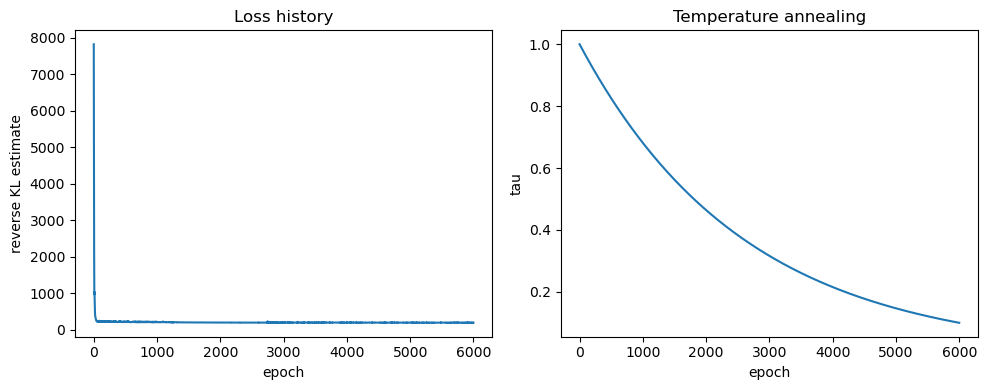

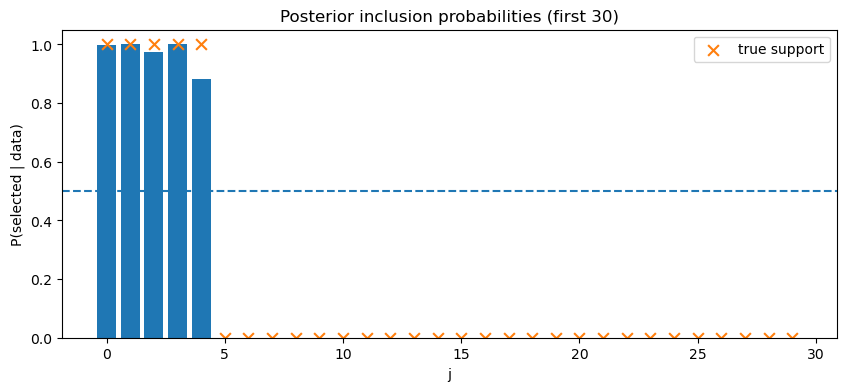

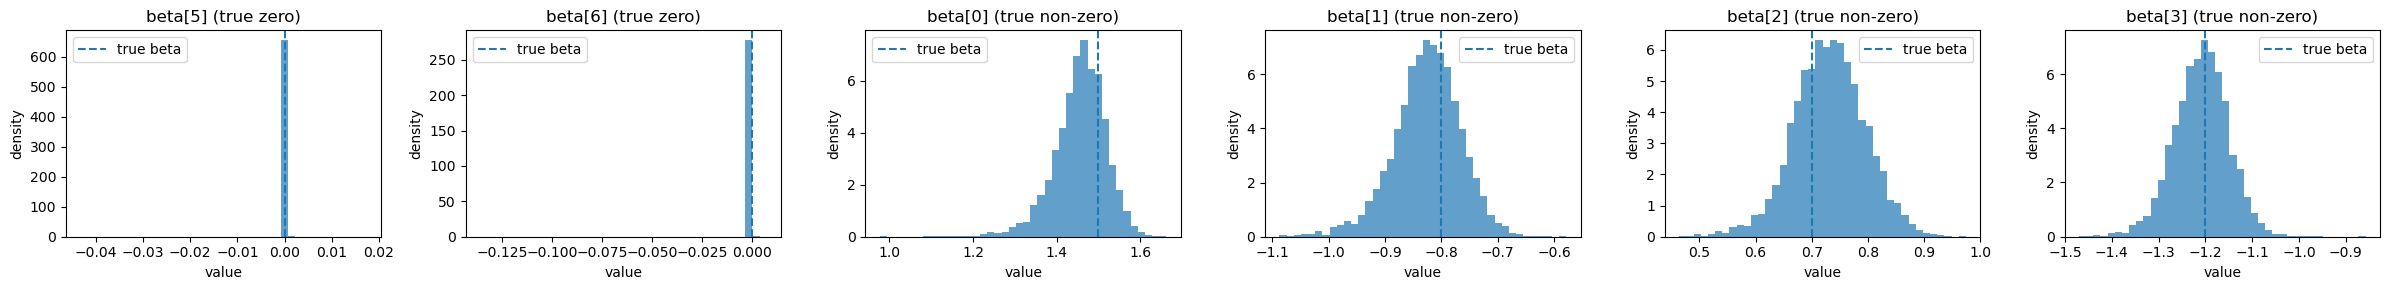

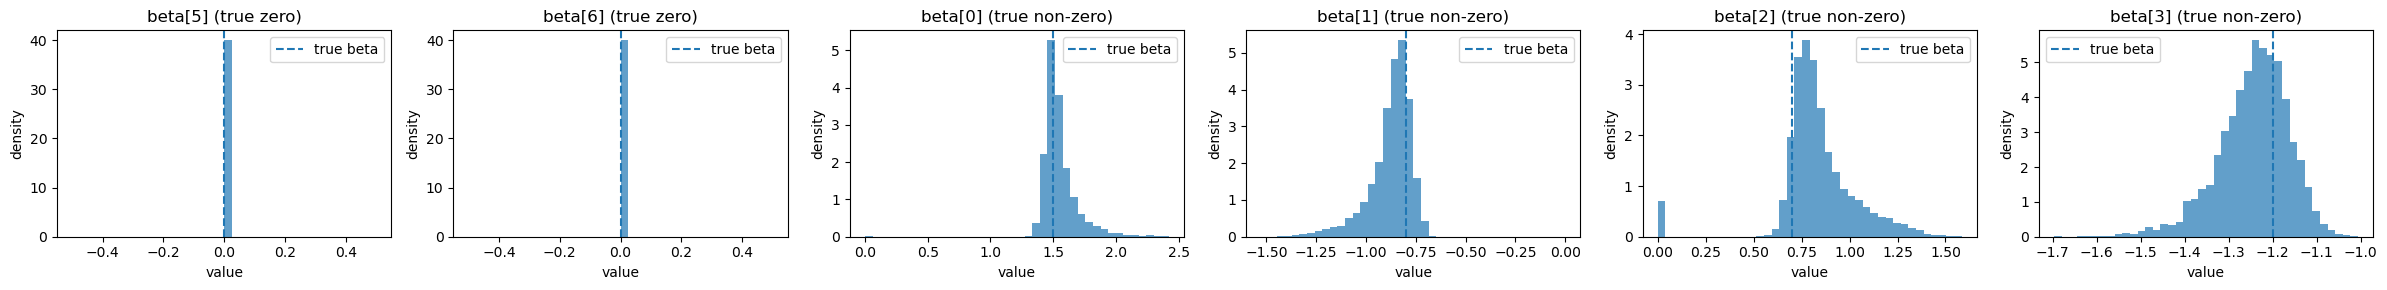

In [5]:
%reload_ext autoreload
post, results = sumfun1(model=model, target_dist=target_dist, n_post_samples=5000, gate_threshold=0.5, inclusion_threshold=0.5,
    beta_true=beta_true, pip_true=None, X_train=None, y_train=None, X_test=None, y_test=None,
    exact_gaussian_mean=None, exact_gaussian_cov=None, losses=losses, tau_hist=tau_hist, make_plots=True,)

In [6]:
def plot_t_diagnostics(post):
    std_normal = Normal(0.0, 1.0)

    t = post["t"].reshape(-1).cpu().numpy()

    t_tensor = post["t"].reshape(-1)
    incl = std_normal.cdf(-t_tensor).cpu().numpy()
    
    gate_hard = post["gate_hard"]
    hard_k = gate_hard.sum(dim=1).cpu().numpy()

    gate_soft = post["gate_soft"]
    soft_k = gate_soft.sum(dim=1).cpu().numpy()

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    axes[0, 0].hist(t, bins=40, density=True)
    axes[0, 0].set_title("Posterior of t")
    axes[0, 0].set_xlabel("t")

    axes[0, 1].hist(incl, bins=40, density=True)
    axes[0, 1].set_title(r"Posterior of $\Phi(-t)$")
    axes[0, 1].set_xlabel(r"$\Phi(-t)$")

    axes[1, 0].hist(hard_k, bins=40, density=True)
    axes[1, 0].set_title("Posterior of hard support size")
    axes[1, 0].set_xlabel(r"$\sum_j \mathbf{1}(m_j > 0)$")

    axes[1, 1].scatter(t, hard_k, alpha=0.35, s=12, label="hard support")
    axes[1, 1].scatter(t, soft_k, alpha=0.35, s=12, label="soft support")
    axes[1, 1].set_title("Threshold vs support size")
    axes[1, 1].set_xlabel("t")
    axes[1, 1].set_ylabel("support size")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

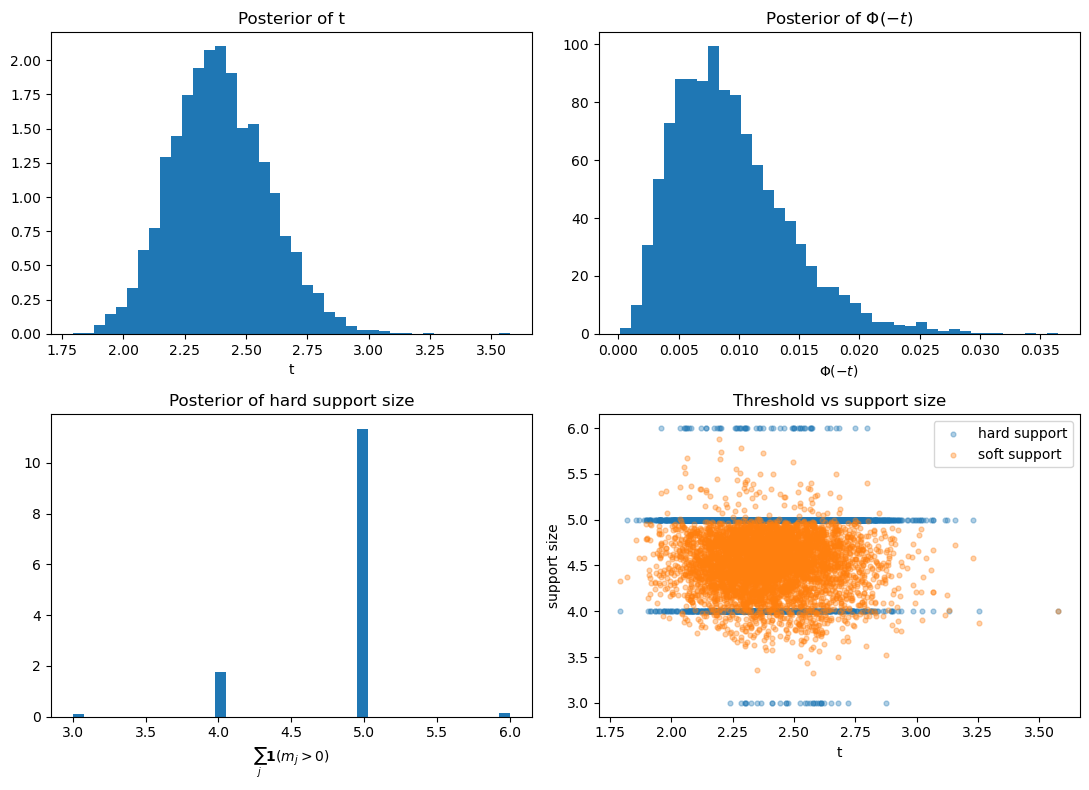

In [8]:
plot_t_diagnostics(post)

In [ ]:
def infer_tau_from_post(post, eps=1e-6):
    u = post["u"]                           # [M, p]
    t = post["t"].reshape(-1, 1)            # [M, 1]
    g = post["gate_soft"]                   # [M, p]

    m = u - t                               # [M, p]

    # avoid logit blow-up at 0 or 1
    g_clip = g.clamp(eps, 1 - eps)
    logit_g = torch.log(g_clip / (1 - g_clip))

    # tau = m / logit(g), only where logit is not near 0
    mask = torch.abs(logit_g) > 1e-8
    tau_vals = (m[mask] / logit_g[mask]).detach()

    # use median for robustness
    tau_hat = tau_vals.median().item()
    return float(tau_hat)


def posterior_reference(post, method="mean", draw_idx=None):
    if method == "mean":
        s_ref = post["s"].mean(dim=0)            # [p]
        u_ref = post["u"].mean(dim=0)            # [p]
        t_ref = post["t"].reshape(-1).mean()     # scalar
    elif method == "sample":
        if draw_idx is None:
            raise ValueError("draw_idx must be provided when method='sample'")
        s_ref = post["s"][draw_idx]
        u_ref = post["u"][draw_idx]
        t_ref = post["t"].reshape(-1)[draw_idx]
    else:
        raise ValueError("method must be 'mean' or 'sample'")
    return s_ref, u_ref, t_ref


def threshold_traversal(post, X, y, tau=None, deltas=None,
                        sigma_y2=1.0, ref_method="mean", draw_idx=None):
    X = fo.to_tensor(X)
    y = fo.to_tensor(y).flatten()

    if tau is None:
        tau = infer_tau_from_post(post)

    if deltas is None:
        deltas = torch.linspace(-2.0, 2.0, steps=81)
    else:
        deltas = fo.to_tensor(deltas).flatten()

    s_ref, u_ref, t_ref = posterior_reference(post, method=ref_method, draw_idx=draw_idx)

    out = {"tau": tau, "delta": [], "t_new": [], "hard_support": [], "soft_support": [], "mse": [], "loglik": [],}

    for d in deltas:
        t_new = t_ref + d
        m_new = u_ref - t_new
        g_new = torch.sigmoid(m_new / tau)
        beta_new = s_ref * g_new

        yhat = X @ beta_new
        mse = torch.mean((y - yhat) ** 2)

        loglik = (
            -0.5 * X.shape[0] * math.log(2.0 * math.pi * sigma_y2)
            -0.5 * torch.sum((y - yhat) ** 2) / sigma_y2
        )

        out["delta"].append(float(d.item()))
        out["t_new"].append(float(t_new.item()))
        out["hard_support"].append(float((m_new > 0).float().sum().item()))
        out["soft_support"].append(float(g_new.sum().item()))
        out["mse"].append(float(mse.item()))
        out["loglik"].append(float(loglik.item()))

    return out


def plot_threshold_traversal(trav):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(trav["t_new"], trav["hard_support"], label="hard support")
    axes[0].plot(trav["t_new"], trav["soft_support"], label="soft support")
    axes[0].set_title("Support path along t")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("support size")
    axes[0].legend()

    axes[1].plot(trav["t_new"], trav["mse"])
    axes[1].set_title("Prediction MSE along t")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("MSE")

    axes[2].plot(trav["t_new"], trav["loglik"])
    axes[2].set_title("Log-likelihood along t")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel(r"$\log p(y \mid \beta(t))$")

    plt.tight_layout()
    plt.show()

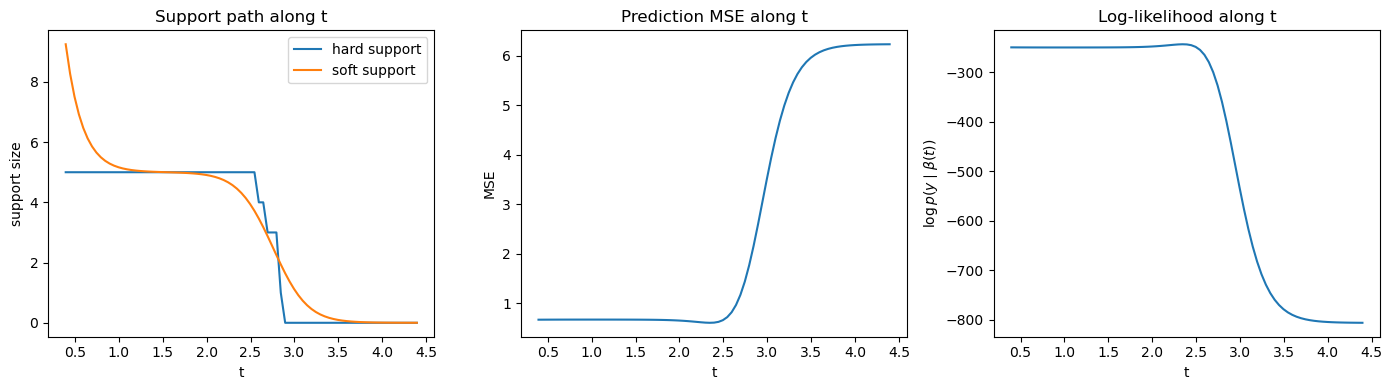

In [10]:
trav = threshold_traversal(post, X, y)
plot_threshold_traversal(trav)

In [11]:
def plot_margin_posteriors(post, indices, labels=None, bins=60):
    u = post["u"]                      # [M, p]
    t = post["t"].reshape(-1, 1)       # [M, 1]
    m = (u - t).cpu().numpy()          # [M, p]

    plt.figure(figsize=(8, 5))
    for k, j in enumerate(indices):
        lab = f"j={j}" if labels is None else labels[k]
        plt.hist(m[:, j], bins=bins, density=True, histtype="step", linewidth=2, label=lab)

    plt.axvline(0.0, linestyle="--")
    plt.title("Posterior of selection margins")
    plt.xlabel(r"$m_j = u_j - t$")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

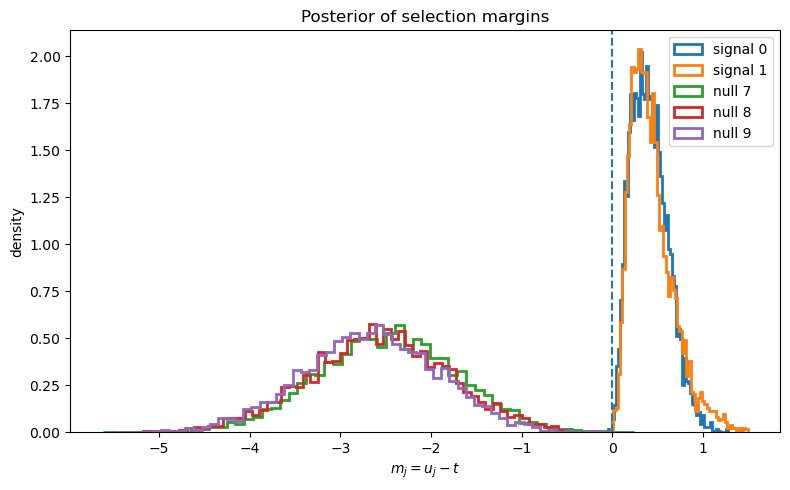

In [13]:
plot_margin_posteriors(
    post,
    indices=[0, 1, 7, 8, 9],
    labels=["signal 0", "signal 1", "null 7", "null 8", "null 9"]
)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pip_vs_margin(post):
    u = post["u"]                        # [M, p]
    t = post["t"].reshape(-1, 1)         # [M, 1]
    m = u - t                            # [M, p]

    mean_m = m.mean(dim=0).cpu().numpy()
    pip = post["pip"].cpu().numpy()

    plt.figure(figsize=(6, 5))
    plt.scatter(mean_m, pip, alpha=0.7)
    plt.axvline(0.0, linestyle="--")
    plt.axhline(0.5, linestyle="--")
    plt.xlabel(r"posterior mean margin $E[m_j \mid y]$")
    plt.ylabel(r"PIP$_j = P(m_j > 0 \mid y)$")
    plt.title("PIP vs posterior mean margin")
    plt.tight_layout()
    plt.show()


def plot_pip_vs_abs_margin(post):
    u = post["u"]                        # [M, p]
    t = post["t"].reshape(-1, 1)         # [M, 1]
    m = u - t                            # [M, p]

    mean_m = m.mean(dim=0).cpu().numpy()
    pip = post["pip"].cpu().numpy()
    uncertainty = np.minimum(pip, 1 - pip)

    plt.figure(figsize=(6, 5))
    plt.scatter(np.abs(mean_m), uncertainty, alpha=0.7)
    plt.xlabel(r"$|E[m_j \mid y]|$")
    plt.ylabel(r"$\min(\mathrm{PIP}_j, 1-\mathrm{PIP}_j)$")
    plt.title("Boundary distance vs selection uncertainty")
    plt.tight_layout()
    plt.show()

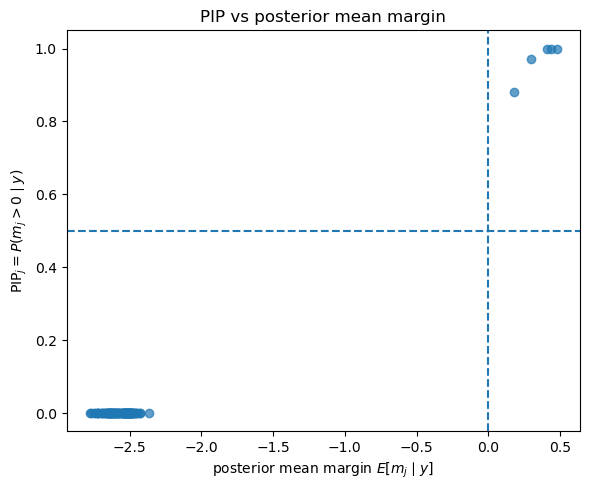

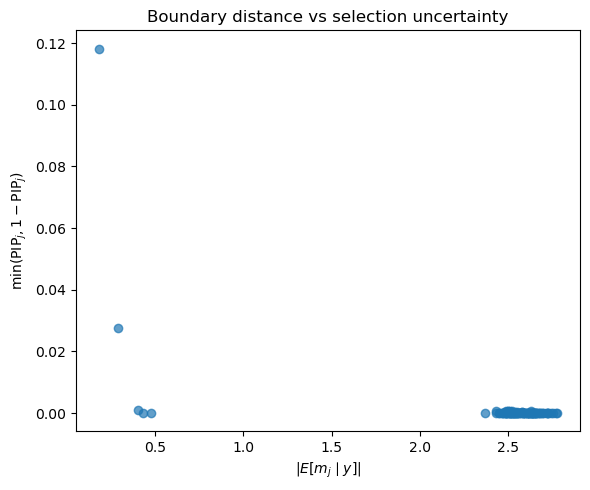

In [16]:
plot_pip_vs_margin(post)
plot_pip_vs_abs_margin(post)

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def safe_corr(x, y, eps=1e-12):
    x = x - x.mean()
    y = y - y.mean()
    denom = (x.std(unbiased=False) * y.std(unbiased=False)).item()
    if denom < eps:
        return float("nan")
    return (x * y).mean().item() / denom


def compute_ms_correlations(post):
    u = post["u"]                      # [M, p]
    t = post["t"].reshape(-1, 1)       # [M, 1]
    m = u - t                          # [M, p]
    s = post["s"]                      # [M, p]

    M, p = m.shape
    corrs = []
    for j in range(p):
        mj = m[:, j]
        sj = s[:, j]
        corrs.append(safe_corr(mj, sj))
    return np.array(corrs)


def plot_ms_corr_hist(post):
    corrs = compute_ms_correlations(post)
    corrs = corrs[np.isfinite(corrs)]

    plt.figure(figsize=(6, 4))
    plt.hist(corrs, bins=40, density=True)
    plt.title(r"Posterior correlations between $m_j$ and $s_j$")
    plt.xlabel(r"$\mathrm{corr}(m_j, s_j)$")
    plt.tight_layout()
    plt.show()

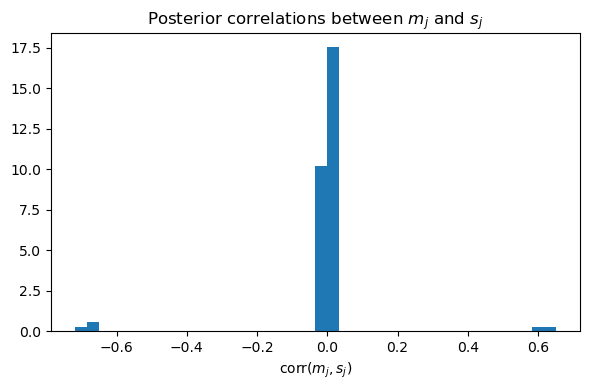

In [18]:
plot_ms_corr_hist(post)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def conditional_magnitude_summary(post):
    u = post["u"]                      # [M, p]
    t = post["t"].reshape(-1, 1)       # [M, 1]
    m = u - t                          # [M, p]

    beta = post["beta_soft"]           # [M, p]
    s = post["s"]                      # [M, p]
    gamma = post["gate_hard"]          # [M, p]
    _, p = m.shape

    mean_abs_beta_cond = []
    mean_abs_s_cond = []
    pip = post["pip"].cpu().numpy()

    for j in range(p):
        mask = gamma[:, j] > 0.5
        if mask.sum().item() == 0:
            mean_abs_beta_cond.append(np.nan)
            mean_abs_s_cond.append(np.nan)
        else:
            mean_abs_beta_cond.append(beta[mask, j].abs().mean().item())
            mean_abs_s_cond.append(s[mask, j].abs().mean().item())

    return {
        "mean_abs_beta_cond": np.array(mean_abs_beta_cond),
        "mean_abs_s_cond": np.array(mean_abs_s_cond),
        "pip": pip,
    }


def plot_conditional_magnitude(post):
    out = conditional_magnitude_summary(post)
    x = out["mean_abs_s_cond"]
    y = out["mean_abs_beta_cond"]

    mask = np.isfinite(x) & np.isfinite(y)

    plt.figure(figsize=(6, 5))
    plt.scatter(x[mask], y[mask], alpha=0.7)
    plt.xlabel(r"$E[|s_j| \mid m_j > 0]$")
    plt.ylabel(r"$E[|\tilde{\beta}_j| \mid m_j > 0]$")
    plt.title("Conditional magnitude after crossing the boundary")
    plt.tight_layout()
    plt.show()

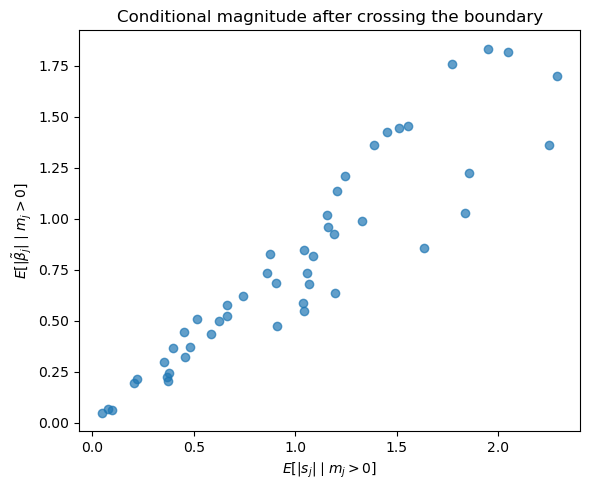

In [20]:
plot_conditional_magnitude(post)

In [ ]:
def boundary_near_variables(post, k=10, criterion="pip"):
    """
    Return indices of variables closest to the selection boundary.
    criterion:
      - "pip"    : closest to 0.5
      - "margin" : smallest |E[m_j]|
    """
    if criterion == "pip":
        pip = post["pip"].cpu().numpy()
        score = np.abs(pip - 0.5)
        idx = np.argsort(score)[:k]
    elif criterion == "margin":
        mean_m = post["m"].mean(dim=0).cpu().numpy()
        score = np.abs(mean_m)
        idx = np.argsort(score)[:k]
    else:
        raise ValueError("criterion must be 'pip' or 'margin'")
    return idx

In [27]:
import math
import numpy as np
import torch
from torch.distributions import Normal


def gaussian_loglik(y, Xbeta, sigma_y2):
    n = y.numel()
    resid = y - Xbeta
    return -0.5 * n * math.log(2.0 * math.pi * sigma_y2) - 0.5 * torch.sum(resid ** 2) / sigma_y2


def slab_logprior_s(s, slab="laplace", lam=1.0, sigma_s=1.0):
    if slab == "laplace":
        return s.numel() * math.log(lam / 2.0) - lam * torch.abs(s).sum()
    elif slab == "gaussian":
        dist = Normal(0.0, sigma_s)
        return dist.log_prob(s).sum()
    else:
        raise ValueError("slab must be 'laplace' or 'gaussian'")


def prior_u_logprob(u):
    dist = Normal(0.0, 1.0)
    return dist.log_prob(u).sum()


def prior_t_logprob(t, mu_t=0.0, sigma_t=1.0):
    dist = Normal(mu_t, sigma_t)
    return dist.log_prob(t)


def resolve_tau(tau):
    """
    Accept either:
      - scalar tau
      - tensor/list/array tau history
    and return a float scalar.
    """
    if isinstance(tau, torch.Tensor):
        if tau.numel() == 1:
            return float(tau.item())
        return float(tau.reshape(-1)[-1].item())
    if isinstance(tau, (list, tuple, np.ndarray)):
        return float(np.array(tau).reshape(-1)[-1])
    return float(tau)


def neg_local_objective_primitive(
    xi, X, y, tau, sigma_y2=1.0,
    slab="laplace", lam=1.0, sigma_s=1.0,
    mu_t=0.0, sigma_t=1.0,
    log_q_fn=None
):
    """
    xi = [s, u, t], shape (2p+1,)
    Returns:
      -(log p(y,xi))            if log_q_fn is None
      log q(xi) - log p(y,xi)   if log_q_fn is provided
    """
    tau = resolve_tau(tau)

    p = X.shape[1]
    s = xi[:p]
    u = xi[p:2*p]
    t = xi[-1]

    m = u - t
    g = torch.sigmoid(m / tau)
    beta = s * g

    log_joint = (
        gaussian_loglik(y, X @ beta, sigma_y2)
        + slab_logprior_s(s, slab=slab, lam=lam, sigma_s=sigma_s)
        + prior_u_logprob(u)
        + prior_t_logprob(t, mu_t=mu_t, sigma_t=sigma_t)
    )

    if log_q_fn is None:
        return -log_joint
    else:
        return log_q_fn(xi) - log_joint


def neg_local_objective_margin(
    eta, X, y, tau, sigma_y2=1.0,
    slab="laplace", lam=1.0, sigma_s=1.0,
    mu_t=0.0, sigma_t=1.0,
    log_q_fn_eta=None
):
    """
    eta = [s, m, t], shape (2p+1,)
    Here u = m + t
    Returns:
      -(log p(y,eta))            if log_q_fn_eta is None
      log q(eta) - log p(y,eta)  if log_q_fn_eta is provided
    """
    tau = resolve_tau(tau)

    p = X.shape[1]
    s = eta[:p]
    m = eta[p:2*p]
    t = eta[-1]

    u = m + t
    g = torch.sigmoid(m / tau)
    beta = s * g

    log_joint = (
        gaussian_loglik(y, X @ beta, sigma_y2)
        + slab_logprior_s(s, slab=slab, lam=lam, sigma_s=sigma_s)
        + prior_u_logprob(u)
        + prior_t_logprob(t, mu_t=mu_t, sigma_t=sigma_t)
    )

    if log_q_fn_eta is None:
        return -log_joint
    else:
        return log_q_fn_eta(eta) - log_joint


def hessian_condition_number(obj_fn, x0, ridge=1e-6):
    """
    Compute Hessian at x0 and summarize local curvature.
    Uses absolute eigenvalues because the local objective can be nonconvex.
    """
    x0 = x0.detach().clone().requires_grad_(True)

    H = torch.autograd.functional.hessian(obj_fn, x0)
    H = 0.5 * (H + H.T)

    eigvals = torch.linalg.eigvalsh(H).detach().cpu()
    abs_eigvals = eigvals.abs()

    good = abs_eigvals > ridge
    if good.sum() < 2:
        cond = float("nan")
    else:
        cond = (abs_eigvals[good].max() / abs_eigvals[good].min()).item()

    out = {
        "H": H.detach(),
        "eigvals": eigvals.numpy(),
        "abs_eigvals": abs_eigvals.numpy(),
        "condition_number": cond,
        "num_positive": int((eigvals > ridge).sum().item()),
        "num_negative": int((eigvals < -ridge).sum().item()),
        "num_near_zero": int((abs_eigvals <= ridge).sum().item()),
    }
    return out


def compare_latent_curvature(post, X, y, tau, sigma_y2=1.0,
                             slab="laplace", lam=1.0, sigma_s=1.0,
                             mu_t=0.0, sigma_t=1.0):
    """
    Compare local curvature under:
      primitive coordinates: (s,u,t)
      margin coordinates:    (s,m,t), where m = u - t
    using the current post from postsum().
    """
    tau = resolve_tau(tau)

    X = fo.to_tensor(X)
    y = fo.to_tensor(y).flatten()

    s_bar = post["s"].mean(dim=0)                    # [p]
    u_bar = post["u"].mean(dim=0)                    # [p]
    t_bar = post["t"].reshape(-1).mean().reshape(1)  # [1]

    # post has no "m"; compute it on the fly
    m_bar = (post["u"] - post["t"].reshape(-1, 1)).mean(dim=0)  # [p]

    x0_primitive = torch.cat([s_bar, u_bar, t_bar], dim=0)
    x0_margin = torch.cat([s_bar, m_bar, t_bar], dim=0)

    prim = hessian_condition_number(
        lambda z: neg_local_objective_primitive(
            z, X, y, tau=tau, sigma_y2=sigma_y2,
            slab=slab, lam=lam, sigma_s=sigma_s,
            mu_t=mu_t, sigma_t=sigma_t,
            log_q_fn=None
        ),
        x0_primitive
    )

    marg = hessian_condition_number(
        lambda z: neg_local_objective_margin(
            z, X, y, tau=tau, sigma_y2=sigma_y2,
            slab=slab, lam=lam, sigma_s=sigma_s,
            mu_t=mu_t, sigma_t=sigma_t,
            log_q_fn_eta=None
        ),
        x0_margin
    )

    print("Using tau =", tau)

    print("\nPrimitive latent space (s,u,t):")
    print("  condition number =", prim["condition_number"])
    print("  #positive        =", prim["num_positive"])
    print("  #negative        =", prim["num_negative"])
    print("  #near-zero       =", prim["num_near_zero"])

    print("\nMargin latent space (s,m,t):")
    print("  condition number =", marg["condition_number"])
    print("  #positive        =", marg["num_positive"])
    print("  #negative        =", marg["num_negative"])
    print("  #near-zero       =", marg["num_near_zero"])

    return prim, marg

In [28]:
prim, marg = compare_latent_curvature(
    post, X, y, tau=tau_hist,
    sigma_y2=1.0,
    slab="laplace", lam=1.0, sigma_s=1.0,
    mu_t=0.0, sigma_t=1.0
)

Using tau = 0.1

Primitive latent space (s,u,t):
  condition number = 90914240.0
  #positive        = 102
  #negative        = 7
  #near-zero       = 92

Margin latent space (s,m,t):
  condition number = 79831992.0
  #positive        = 103
  #negative        = 7
  #near-zero       = 91
